# Oefenmodel dwarsdoorsnede ARK 

Dit oefenmodel dient om mechanismen van wellen op regionale schaal
uit te proberen, met name het dichtdrukken van wellen door
uitzetting van de grond in de zomer en de invloed van viscositeit.

import matplotlib
matplotlib.use("QtAgg")

import matplotlib.pyplot as plt
print(matplotlib.get_backend())

loading mfpath.py
NOTEBOOK_NAME = 'experiment_xsec_ARK.ipynb'
Project directory namespace:
rws                  /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/
home                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src
images               /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../images
data                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../data


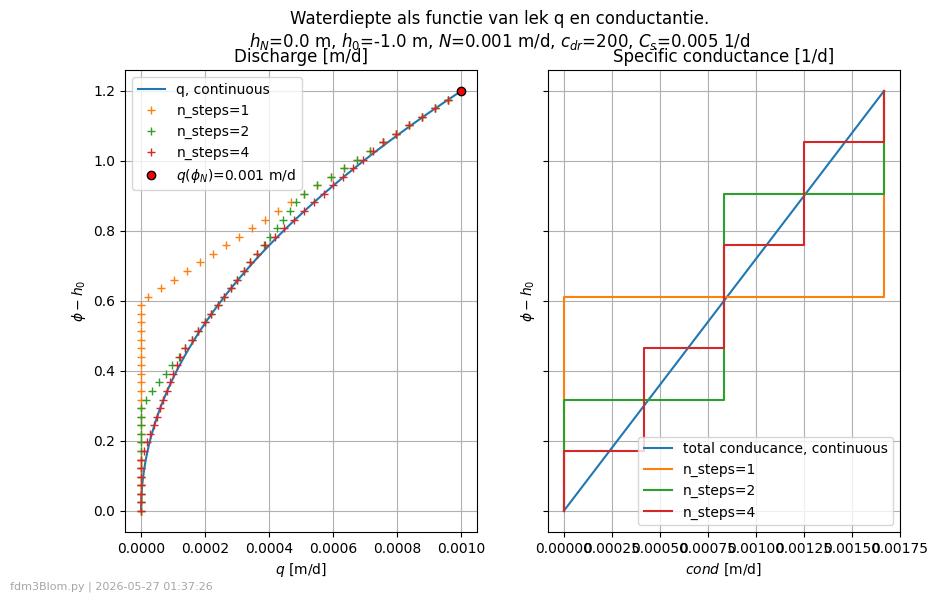

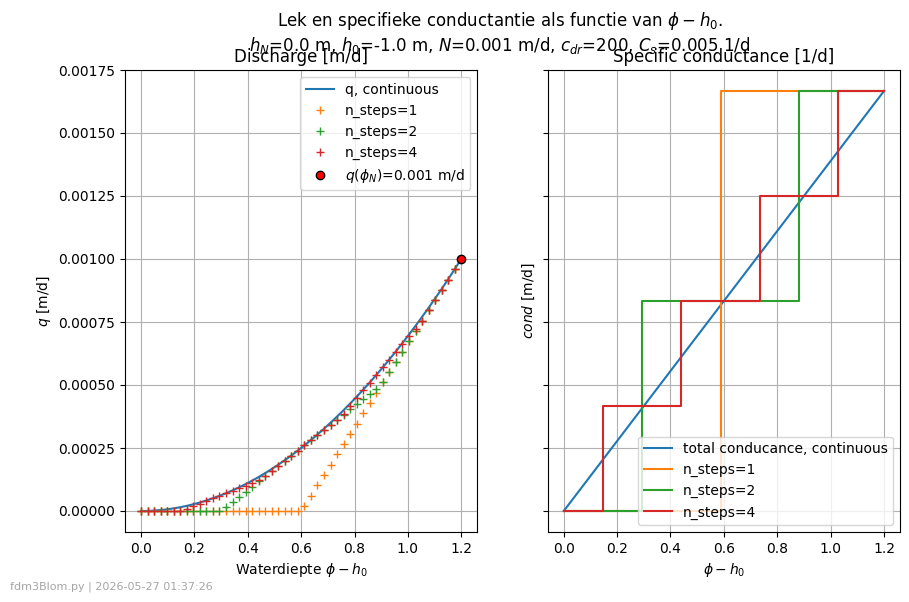

In [1]:
import os
import sys
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import Akima1DInterpolator
from PIL import Image
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import logo, descr, pickleto, picklefrom

NOTEBOOK_NAME = "experiment_xsec_ARK.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home = os.path.join(self.rws, "src")
        self.images = os.path.join(self.home, '../images')
        self.data = os.path.join(self.home, '../data')
        
dirs = Dirs()

# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes

print("Project directory namespace:")
descr(dirs)

## The wellen image (cutout of fig 3.1 in Beemster et all)

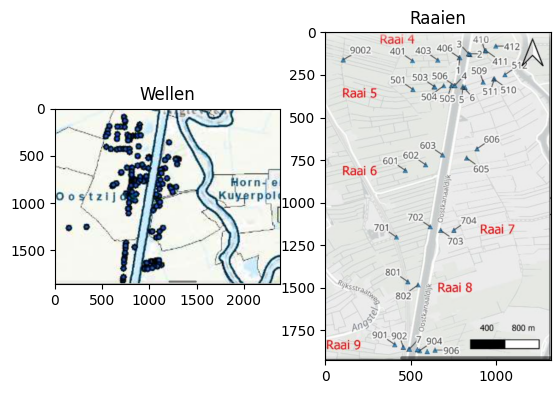

In [2]:
image_wellen = os.path.join(dirs.images,
        "wellen_Beemster_22_fig3_1_128499_131432_473951_476274.png")
image_raaien = os.path.join(dirs.images,
        "raaien_fig2_1_systeemanalyse_Deltares_128127_130749_471773_475601.png")

for image in [image_wellen, image_raaien]:
    assert os.path.isfile(image), f"FileNotFound {image}"

fig, (ax1, ax2) = plt.subplots(1,2)

img_wellen = Image.open(image_wellen)
img_raaien = Image.open(image_raaien)
ax1.imshow(img_wellen)
ax2.imshow(img_raaien)
ax1.set_title("Wellen")
ax2.set_title("Raaien")

plt.show()

In [3]:
from pyproj import Transformer

# --- transformer from WGS84 -> RD New
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:28992",
    always_xy=True
)

# === Geolocating cut-out of fig 3.1 in Beemster (2022)
# --- NW SE (UL, LR) of image
lonlat = np.array([[4.998927,  52.273840],
                   [5.042055,  52.253094]]
)

print("image_wellen extent")
for lon, lat in lonlat:
    x, y = transformer.transform(lon, lat)
    print(np.round(x), np.round(y))
print()


image_wellen extent
128499.0 476274.0
131432.0 473951.0



In [4]:
wellen = picklefrom(os.path.join(dirs.data, 'wellen.pkl'))
raaien = picklefrom(os.path.join(dirs.data, 'raaien.pkl'))

Loaded <function basename at 0x10a9179c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../data/wellen.pkl
Loaded <function basename at 0x10a9179c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../data/raaien.pkl


## ARK bottom profile

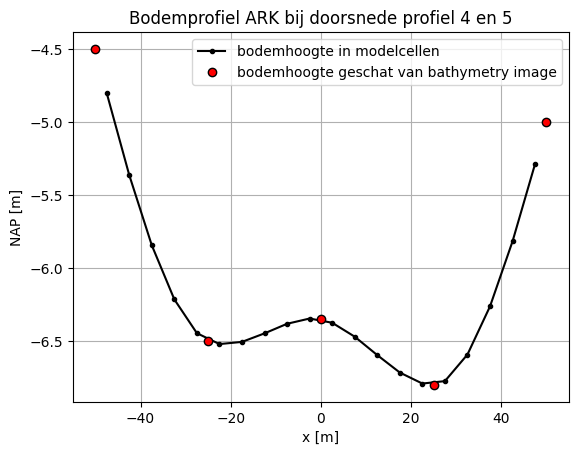

In [5]:
# --- Points estimated from ARK bathymetry image
xark = np.array([-50., -25.,    0.,  25., 50.])
zark = np.array([-4.5, -6.5, -6.35, -6.8, -5.])

# --- Interpolate to get bathymetry profile
interp = Akima1DInterpolator(xark, zark, method='akima', extrapolate=None)

x = np.linspace(-50, 50, 21)
xm = 0.5 * (x[:-1] + x[1:])
zm = interp(xm)

# --- Show profile
fig, ax = plt.subplots()
ax.plot(xm, zm, 'k.-', label='bodemhoogte in modelcellen')
ax.plot(xark, zark, 'ro', mec='k', label='bodemhoogte geschat van bathymetry image')
ax.grid()
ax.set_title("Bodemprofiel ARK bij doorsnede profiel 4 en 5")
ax.set_xlabel('x [m]')
ax.set_ylabel('NAP [m]')
ax.legend()

xm_ark, zm_ark = xm, zm


# The finite difference model

In [6]:
# --- Patches and properties
ARK     = {'b': 50, 'z':[-0.4, -6.7], 'kh':1000., 'kv':1000.,
           'heart_line': np.array([[129810.0, 475695.0], [129006.0, 471010.0]])}

# --- Save profile
ARK['bot'] = np.array([(x_, z_) for x_, z_ in zip(xm_ark, zm_ark)]).round(2)

# --- ARK bottom resistance layer
canal_bot = {'z':[ARK['z'][1] + 0.3, ARK['z'][1]], 'c':10}

damw    = {'z':[   0,  -12.], 'kh': 0.0, 'kv': 0.0,
          'x':[ARK['b'], ARK['b'] + 0.25]}
deklW   = {'z':[-1.9, -5.8], 'kh': 1.0, 'kv': 0.1}
deklE   = {'z':[-1.8, -5.0], 'kh': 1.0, 'kv': 0.1}
boxt    = {'z':[  -10.], 'kh':  5,  'kv':  1.}
pp      = {'W':-2.4, 'E': -1.9}
strk    = {'z':[ -10., -50.], 'kh': 30,  'kv':  6.}

deklW['D'] = deklW['z'][0] - deklW['z'][1]
deklE['D'] = deklE['z'][0] - deklE['z'][1]
deklW['k'] = np.sqrt(deklW['kh'] * deklW['kv'])
deklE['k'] = np.sqrt(deklE['kh'] * deklE['kv'])
sloten = {'x': np.arange(55, 2500, 30), 'b':2, 'd':1}
sloten['omega'] = sloten['b'] * np.pi / 2

ARK['patch'] = Rectangle((-ARK['b'], ARK['z'][1]), 2*ARK['b'], ARK['z'][0] - ARK['z'][1], fc='b', ec='none')
damw['patchW'] = Rectangle((-damw['x'][1], damw['z'][1]), damw['x'][1] - damw['x'][0], damw['z'][0] - damw['z'][1], fc='k', ec='none')
damw['patchE'] = Rectangle(( damw['x'][0], damw['z'][1]), damw['x'][1] - damw['x'][0], damw['z'][0] - damw['z'][1], fc='k', ec='none')


In [7]:
rho_peat, rhow = 1.1, 1.0
ditch_depth = 1.0
print("Onder sloot: ", ((pp['W'] - ditch_depth - deklW['z'][1])) * rho_peat + ditch_depth * rhow)
print("Naast sloot1 ", ((deklW['z'][0] - deklW['z'][1])) * rho_peat)
print("Naast sloot2 ", (deklW['z'][0] - pp['W']) * rho_peat/2 +((pp['W'] - deklW['z'][1])) * rho_peat)
print("Hydrostatisch: ", (pp['W'] - deklW['z'][1]) * rhow)

Onder sloot:  3.64
Naast sloot1  4.29
Naast sloot2  4.015000000000001
Hydrostatisch:  3.4


## Model network

In [8]:
# --- Increasing layer thickness in the Sterksel layer
Dstrk = strk['z'][0] - strk['z'][-1]
zstrk = np.round(strk['z'][0] - np.logspace(0, np.log10(Dstrk), 10), 1)
zstrk

array([-11. , -11.5, -12.3, -13.4, -15.2, -17.8, -21.7, -27.6, -36.5,
       -50. ])

In [9]:
L = 2500.
Dx_grid  = 5.
Dx_sloot = 25.

# --- Use 5 m  grid horizontally
Dx  = 5.0
x = np.hstack((np.linspace(-L, L, int(2 * L / Dx_grid) + 1),
              np.array(damw['x']), -np.array(damw['x'])))

# --- Get useful layer elevations
z = np.round(np.hstack((ARK['z'][-1], deklW['z'][0], deklW['z'][-1], deklE['z'][-1], boxt['z'][-1], zstrk, damw['z'][-1], np.linspace(-2.5, -12, 20))), 2)
z = np.unique(z)[::-1]
print(z)

gr = mfgrid.Grid(x, None, z)
print(f'gr.shape = {gr.shape}')


[ -1.9  -2.5  -3.   -3.5  -4.   -4.5  -5.   -5.5  -5.8  -6.   -6.5  -6.7
  -7.   -7.5  -8.   -8.5  -9.   -9.5 -10.  -10.5 -11.  -11.5 -12.  -12.3
 -13.4 -15.2 -17.8 -21.7 -27.6 -36.5 -50. ]
gr.shape = (30, 1, 1002)


In [10]:
N=10

print('\nx_sloten:')
x_sloten = ARK['b'] + Dx_grid / 2 + np.arange(10, L - ARK['b'], Dx_sloot) # --- Eerste sloot op 12.5 vanaf het kanaal en daarna om de 25 m
x_sloten = np.hstack((-x_sloten[::-1], x_sloten))
print(x_sloten[:N]) 

print("\ny_sloten:")
y_sloten = np.zeros_like(x_sloten)
print(y_sloten[:N])

print("\nz_sloten:")
z_sloten = np.zeros_like(x_sloten)
z_sloten[x_sloten < -ARK['b']] = pp['W'] - 0.5
z_sloten[x_sloten > +ARK['b']] = pp['E'] - 0.5
print(z_sloten[:N])

print("\nix_sloten:")
ix_sloten = np.searchsorted(gr.x, x_sloten) - 1
print(ix_sloten[:N])

xyz_sloten = np.vstack((x_sloten, np.zeros_like(x_sloten), z_sloten)).T
xyz_wellen = np.vstack((x_sloten, np.zeros_like(x_sloten), z_sloten -6.)).T 

# --- Exfiltration resistance for the ditches given the anisotropy of the deklaag
w_sloten = np.round(1 / (np.pi * deklW['k']) * (np.log(deklW['D'] / sloten['omega']) + np.log(np.sqrt(deklW['kh'] /deklW['kv']))), 2)
print(f"\nradiale slootweerstand w: {w_sloten} d/m")



x_sloten:
[-2487.5 -2462.5 -2437.5 -2412.5 -2387.5 -2362.5 -2337.5 -2312.5 -2287.5
 -2262.5]

y_sloten:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

z_sloten:
[-2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9]

ix_sloten:
[ 2  7 12 17 22 27 32 37 42 47]

radiale slootweerstand w: 1.38 d/m


In [11]:
gr = mfgrid.Grid(x, None, z)

# %% Masks
ARK['mask'] = ((gr.ZM <= ARK['z'][0]) &
               (gr.ZM >= ARK['z'][-1]) &
               (gr.XM <= +ARK['b']) &
               (gr.XM >= -ARK['b'])
)

canal_bot['mask'] = (ARK['mask'] &
              (gr.ZM < canal_bot['z'][0]) &
              (gr.ZM > canal_bot['z'][1]))

damw['mask'] = (((gr.XM >= damw['x'][0]) &
                (gr.XM <= damw['x'][-1]) &
                (gr.ZM >= damw['z'][-1]))
                |
               ((gr.XM <= -damw['x'][0]) &
                (gr.XM >= -damw['x'][-1]) &
                (gr.ZM <= damw['z'][0]) &
                (gr.ZM >= damw['z'][-1]))
)
deklW['mask'] = ((gr.ZM <= deklW['z'][0]) &
                 (gr.ZM >= deklW['z'][-1]) &
                 (gr.XM <= 0)
)

deklE['mask'] = ((gr.ZM <= deklW['z'][0]) &
                 (gr.ZM >= deklW['z'][-1]) &
                 (gr.XM >= 0.)
)

boxt['mask'] = (((gr.ZM <= deklW['z'][-1]) &
                (gr.ZM >= boxt['z'][-1]) &
                (gr.XM <= 0))
                 |
                ((gr.ZM <= deklE['z'][-1]) &
                 (gr.ZM >= boxt['z'][-1]) &
                 (gr.XM >= 0))
                )

strk['mask'] = ((gr.ZM <= boxt['z'][-1]) &
                (gr.ZM >= strk['z'][-1])
)


# --- Prevent overlap with damw and ARK
for mask in [deklW, deklE, boxt, strk]:
    mask['mask'] = mask['mask'] & ~damw['mask'] & ~ARK['mask']

# --- Attribute properties to masked zones
kh = gr.const(0.)
kv = gr.const(0.)
for zone in [deklW, deklE, boxt, strk, ARK, damw]:
    kh[zone['mask']] = zone['kh']
    kv[zone['mask']] = zone['kv']
    
mask = canal_bot['mask']
kv[mask] = 0.5 * gr.DZ[mask] / canal_bot['c']

IBOUND = gr.const(1, dtype=int)
IBOUND[ARK['mask']] = -1
IBOUND[damw['mask']] = 0

GHB = np.zeros(len(x_sloten), dtype=dtypes['ghb']) # dtype([('Ig', '<i8'), ('h', '<f8'), ('C', '<f8')])
GHB['Ig'] = gr.Iglob_from_xyz(xyz_sloten)
GHB['h'] = pp['W']
GHB['C'] = 1 / w_sloten

DRN = np.zeros(len(x_sloten), dtype=dtypes['drn']) # dtype([('Ig', '<i8'), ('h', '<f8'), ('C', '<f8')])
DRN['Ig'][:] = gr.Iglob_from_xyz(xyz_wellen)
DRN['h'] = pp['W'] + 0.5 # --- Check with real numbers (The extra head between ditches so that top layer does not float)
w_wellen = 4 # computed at c=100 d for a wel at 25 m so w d/m * 25 m = 100  d--> w = 4 d/m
DRN['C'] = 1 / w_wellen

HI = gr.const(pp['W'])
HI[deklW['mask']] = pp['W']
HI[deklE['mask']] = pp['E']
HI[ARK['mask']] = ARK['z'][0]

Ss = gr.const(0.0001)

FQ = gr.const(0.)

mdl = fdm3Blom.Fdm3(gr=gr, K=(kh, kh, kv), c=None, S=Ss, IBOUND=IBOUND, HI=HI, FQ=FQ)

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:234: RuntimeWarning: divide by zero encountered in divide
  Rx2 = 0.5 * dx / (dy * dz) / kx
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:235: RuntimeWarning: divide by zero encountered in divide
  Rx1 = 0.5 * dx / (dy * dz) / kx
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:236: RuntimeWarning: divide by zero encountered in divide
  Ry  = 0.5 * dy / (dz * dx) / ky
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:237: RuntimeWarning: divide by zero encountered in divide
  Rz  = 0.5 * dz / (dx * dy) / kz


In [12]:
out = mdl.simulate(DRN=DRN, RIV=None, GHB=GHB, FDR=None, tm=[1, 1.5], verbose=False)

gr.dphi = 0.1 
gr.dpsi = 0.25

out['gr'] = gr
out['psi'] = gr.psi_row(out['Qx'])

# --- phi and psi levels for contourin heads and stream lines    
phi_levels = np.arange(np.floor(pp['W']), np.ceil(ARK['z'][0]), gr.dphi)
psi_levels = np.arange(np.floor(out['psi'].min()), np.ceil(out['psi'].max()), gr.dpsi)


Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =    0.93309 m, errBalance =     1.6165
iouter =    1, err =   0.083762 m, errBalance =    0.47516
iouter =    2, err =   0.011098 m, errBalance =   0.091364
iouter =    3, err =  0.0013964 m, errBalance =   0.014199
iouter =    4, err = 0.00013372 m, errBalance =  0.0015872
iouter =    5, err = 9.2348e-06 m, errBalance = 0.00012384
iouter =    6, err = 4.4999e-07 m, errBalance = 6.6658e-06
iouter =    7, err = 1.5281e-08 m, errBalance = 2.4533e-07
Converged, normal termination.

===== Water balance of the entire model =====
Model grid = (30, 1, 1002)

Sum over all nodal flows should be zero:
Total net in Q1     = -9.1343e-11 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =           0.000 m3/d
Fixed heads         QFH  =           5.059 m3/d
GHB                Qghb =          -4.874 m3/d, flow from GHB cells.
DRN                Qdrn  =          -0.184 m3/d

Total

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/mfgrid.py:2020: UserWarning: This only works when all flow is within plane zx given by row
  warnings.warn("This only works when all flow is within plane zx given by row")


In [13]:
print(f"cbottom = {canal_bot['c']:.1f} d, Inf = {out['Qfh']['Q'].sum():.2f}, Sloten(GHB)= {out['GHB']['Q'].sum():.2f}, wellen('DRN) = {out['DRN']['Q'].sum():.2f} m2/d")

cbottom = 10.0 d, Inf = 5.06, Sloten(GHB)= -4.87, wellen('DRN) = -0.18 m2/d


## Show the cross section

/var/folders/90/m51x_b713y561gzh2kzy18d00000gq/T/ipykernel_72456/729173001.py:5: RuntimeWarning: divide by zero encountered in log
  ax.pcolormesh(gr.X[:,0,:-1], gr.Z[:,0,:], np.log(kh[:,0,:-1]), cmap='viridis')
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/mfgrid.py:2020: UserWarning: This only works when all flow is within plane zx given by row
  warnings.warn("This only works when all flow is within plane zx given by row")


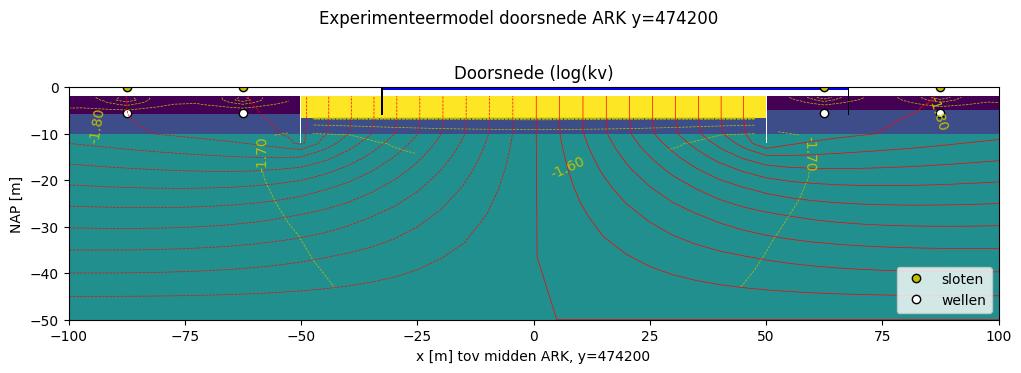

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
# ax.imshow(np.squeeze(np.log(kh)), origin='upper', cmap='gray')

# ax.pcolormesh(gr.X[:,0,:-1], gr.Z[:,0,:], IBOUND[:,0,:-1], cmap='gray')
ax.pcolormesh(gr.X[:,0,:-1], gr.Z[:,0,:], np.log(kh[:,0,:-1]), cmap='viridis')
ax.plot(x_sloten, y_sloten, 'yo', mec='k', label='sloten')
ax.plot(x_sloten, deklE['z'][1] * np.ones_like(y_sloten) - 0.5, 'wo', mec='k', label='wellen')

psi = gr.psi_row(out['Qx'])

phi_min, phi_max = out['Phi'].min(), out['Phi'].max()
psi_min, psi_max = psi.min(), psi.max()

cs_phi = ax.contour(gr.xm, gr.zm, out['Phi'][:, 0, :], colors='y', linewidths=0.5, levels=phi_levels)
cs_psi = ax.contour(gr.x[1:-1], gr.z, psi, colors='r', linewidths=0.5, levels=psi_levels)

ax.clabel(cs_phi, levels=cs_phi.levels, fontsize=10, fmt='%.2f')

try:
    ARK['patch'].remove()
    damw['patchW'].remove()
    damw['patchE'].remove()
except NotImplementedError:
    pass

ax.add_patch(ARK['patch'])
ax.add_patch(damw['patchW'])
ax.add_patch(damw['patchE'])

ax.set_aspect(1)
ax.set_xlim(-100, 100)
ax.set_ylim(-50, 0)
ax.legend(loc='lower right')

fig.suptitle(f"Experimenteermodel doorsnede ARK y={474200}")
ax.set_title("Doorsnede (log(kv)")
ax.set_xlabel('x [m] tov midden ARK, y=474200')
ax.set_ylabel('NAP [m]')

plt.show()
plt.close('all')


In [22]:
out['Phi'][:, 0, 500]

array([-0.4       , -0.4       , -0.4       , -0.4       , -0.4       ,
       -0.4       , -0.4       , -0.4       , -0.4       , -0.4       ,
       -0.4       , -1.39409978, -1.40899099, -1.43375248, -1.45845541,
       -1.48309846, -1.5076803 , -1.53219968, -1.55665535, -1.56066639,
       -1.56461236, -1.56849315, -1.57230868, -1.57457449, -1.58256641,
       -1.59480023, -1.61073358, -1.63086283, -1.65340725, -1.67221263])

In [23]:
kv[:,0,500]

array([1.e+03, 1.e+03, 1.e+03, 1.e+03, 1.e+03, 1.e+03, 1.e+03, 1.e+03,
       1.e+03, 1.e+03, 1.e-02, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00,
       1.e+00, 1.e+00, 6.e+00, 6.e+00, 6.e+00, 6.e+00, 6.e+00, 6.e+00,
       6.e+00, 6.e+00, 6.e+00, 6.e+00, 6.e+00, 6.e+00])

In [24]:
gr.z

array([ -1.9,  -2.5,  -3. ,  -3.5,  -4. ,  -4.5,  -5. ,  -5.5,  -5.8,
        -6. ,  -6.5,  -6.7,  -7. ,  -7.5,  -8. ,  -8.5,  -9. ,  -9.5,
       -10. , -10.5, -11. , -11.5, -12. , -12.3, -13.4, -15.2, -17.8,
       -21.7, -27.6, -36.5, -50. ])

In [28]:
out['Qfh']['Q'].sum() / (2 * ARK['b']), -np.diff(out['Phi'][:, 0, 500])/canal_bot['c']

(np.float64(0.05058653070987831),
 array([-0.        , -0.        , -0.        , -0.        , -0.        ,
        -0.        , -0.        , -0.        , -0.        , -0.        ,
         0.09940998,  0.00148912,  0.00247615,  0.00247029,  0.0024643 ,
         0.00245818,  0.00245194,  0.00244557,  0.0004011 ,  0.0003946 ,
         0.00038808,  0.00038155,  0.00022658,  0.00079919,  0.00122338,
         0.00159333,  0.00201293,  0.00225444,  0.00188054]))